<a href="https://colab.research.google.com/github/linhtutkyawdev/my_aggri_cner_v2/blob/master/my_agri_cner_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Burmese Agriculture CNER: Automated 5-Fold Cross-Validation Pipeline (With Auto-Resume)
This notebook is an enhanced, highly-professional version of the legacy Colab file. Instead of training on a single random split, it automates **5-Fold Cross-Validation** for all 4 standard CoNLL file formats (`bio_word`, `bio_syllable`, `bioes_word`, `bioes_syllable`), evaluates them using a standard entity-level metric, and reports the average Precision, Recall, and F1-Score along with their standard deviations.

### 💾 Colab Disconnect Protection & Auto-Resume
To protect against Google Colab timeouts, inactivity disconnects, or runtime restarts:
1. **Real-time Persistence**: The splits (`data/`), model checkpoints (`models/`), and prediction files (`output/`) are symlinked and written directly to your **Google Drive** in real-time.
2. **Auto-Resume**: If Colab disconnects, you can simply run all cells again. The training loop detects already completed folds and automatically skips them, parsing existing predictions to compute the final averages immediately. This saves days of training time!


### Step 1: Connect to Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Step 2: Configure Environment and Paths


In [2]:
import os
import sys
import shutil

# Project directory in Google Drive
%env PJ_DIR=/content/drive/My Drive/MyAgriNER_copy
project_root = '/NCRFpp'

print(f'Project execution root is: {project_root}')


env: PJ_DIR=/content/drive/My Drive/MyAgriNER_copy
Project execution root is: /NCRFpp


### Step 3: Clone NCRFpp Repository & Install Dependencies


In [3]:
if not os.path.exists('/NCRFpp'):
    !git clone https://github.com/jiesutd/NCRFpp.git /NCRFpp
else:
    print('NCRFpp repository already exists.')

# Install the necessary libraries
with open('requirements.txt', 'w') as f:
    f.write('torch\nnumpy\n')
!pip install -r requirements.txt


Cloning into '/NCRFpp'...
remote: Enumerating objects: 768, done.
remote: Total 768 (delta 0), reused 0 (delta 0), pack-reused 768 (from 1)
Receiving objects: 100% (768/768), 6.89 MiB | 15.37 MiB/s, done.
Resolving deltas: 100% (484/484), done.


### Step 4: Persistent Google Drive Symlinking & Dataset Extraction


In [4]:
import os
import shutil

# 1. Define persistent directories in Google Drive
drive_root = '/content/drive/My Drive/MyAgriNER'
drive_data = os.path.join(drive_root, 'data')
drive_models = os.path.join(drive_root, 'models')
drive_output = os.path.join(drive_root, 'output')

# Create directories on Google Drive if they don't exist
os.makedirs(drive_data, exist_ok=True)
os.makedirs(drive_models, exist_ok=True)
os.makedirs(drive_output, exist_ok=True)

# 2. Extract data.zip directly to Google Drive (only if bio_word folder or emb files are missing to save time!)
already_extracted = os.path.exists(os.path.join(drive_data, 'bio_word')) and any(f.endswith('.emb') for f in os.listdir(drive_data)) if os.path.exists(drive_data) else False

if not already_extracted:
    zip_paths = [
        "/content/data.zip",
        "/content/drive/My Drive/MyAgriNER/data.zip",
        "/content/drive/My Drive/data.zip"
    ]
    found_zip = None
    for p in zip_paths:
        if os.path.exists(p):
            found_zip = p
            break

    if found_zip:
        print(f"Found data.zip at: {found_zip}")
        print("Extracting data.zip directly to Google Drive... This may take a minute.")
        !unzip -q -o "{found_zip}" -d "/content/drive/My Drive/MyAgriNER/"
        print("Extraction complete!")
    else:
        print("Warning: data.zip not found! If you have not uploaded pre-split folders, please upload data.zip to Google Drive (MyAgriNER/) or Colab (/content/).")
else:
    print("Data directory already exists and contains extracted files on Google Drive. Skipping extraction.")

# 3. Symlink /NCRFpp directories to Google Drive
for folder, drive_path in [('data', drive_data), ('models', drive_models), ('output', drive_output)]:
    local_path = f'/NCRFpp/{folder}'
    if os.path.exists(local_path):
        if os.path.islink(local_path):
            os.unlink(local_path)
        else:
            shutil.rmtree(local_path)
    os.symlink(drive_path, local_path)
    print(f'Symlinked local {local_path} -> persistent Google Drive: {drive_path}')


Found data.zip at: /content/drive/My Drive/data.zip
Extracting data.zip directly to Google Drive... This may take a minute.
Extraction complete!
Symlinked local /NCRFpp/data -> persistent Google Drive: /content/drive/My Drive/MyAgriNER/data
Symlinked local /NCRFpp/models -> persistent Google Drive: /content/drive/My Drive/MyAgriNER/models
Symlinked local /NCRFpp/output -> persistent Google Drive: /content/drive/My Drive/MyAgriNER/output


### Step 5: Robust K-Fold Dataset Splitter (Rotating Blocks)
Instead of random shuffling (which breaks cross-validation sequence standards), this cell splits each standard CoNLL file into 5 fold directories under `data/{setup_name}/fold_{fold_idx}/` containing standard `train.conll`, `dev.conll`, and `test.conll` files, respecting sentence boundaries.

**Smart Skipping**: It automatically checks your Google Drive, and if the split folders are already generated, it skips this process to save time.


In [5]:
import os
from pathlib import Path

def load_conll_sentences(file_path):
    """Parses a CoNLL file and returns a list of raw sentence blocks."""
    sentences = []
    current_sentence = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            current_sentence.append(line)
            if not line.strip():
                if current_sentence:
                    sentences.append("".join(current_sentence))
                    current_sentence = []
        if current_sentence:
            content = "".join(current_sentence)
            if not content.endswith('\n'):
                content += '\n'
            if not content.endswith('\n\n'):
                content += '\n'
            sentences.append(content)
    return sentences

def split_sentences_by_ratio(sentences, ratio, folds):
    """Splits sentences into folds using rotating block selection."""
    B = sum(ratio)
    N = len(sentences)
    X, Y, Z = ratio

    folds_data = []
    for i in range(folds):
        S_i = int(i * B / folds)

        # Rotating block indices modulo B
        train_blocks = [(S_i + b) % B for b in range(X)]
        dev_blocks = [(S_i + X + b) % B for b in range(Y)]
        test_blocks = [(S_i + X + Y + b) % B for b in range(Z)]

        def get_sentences_for_blocks(blocks):
            selected = []
            for b in sorted(blocks):
                start_idx = int(b * N / B)
                end_idx = int((b + 1) * N / B)
                selected.extend(sentences[start_idx:end_idx])
            return selected

        train_sents = get_sentences_for_blocks(train_blocks)
        dev_sents = get_sentences_for_blocks(dev_blocks)
        test_sents = get_sentences_for_blocks(test_blocks)

        folds_data.append((train_sents, dev_sents, test_sents))
    return folds_data

def process_file(file_path, output_dir, ratio, folds):
    print(f"Processing CoNLL file: '{file_path}'")
    sentences = load_conll_sentences(file_path)
    print(f"  Loaded {len(sentences)} sentences.")

    folds_data = split_sentences_by_ratio(sentences, ratio, folds)
    base_name = Path(file_path).stem

    setup_dir = Path(output_dir) / base_name
    setup_dir.mkdir(parents=True, exist_ok=True)

    for i, (train, dev, test) in enumerate(folds_data):
        fold_dir = setup_dir / f"fold_{i}"
        fold_dir.mkdir(parents=True, exist_ok=True)

        with open(fold_dir / "train.conll", 'w', encoding='utf-8') as f:
            f.writelines(train)
        with open(fold_dir / "dev.conll", 'w', encoding='utf-8') as f:
            f.writelines(dev)
        with open(fold_dir / "test.conll", 'w', encoding='utf-8') as f:
            f.writelines(test)

        print(f"    Fold {i} -> Train: {len(train)} sents, Dev: {len(dev)} sents, Test: {len(test)} sents")

data_dir = '/NCRFpp/data'

# Check if splits are already present on Google Drive
has_splits = False
if os.path.exists(data_dir):
    subdirs = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    for subdir in subdirs:
        if 'fold_0' in os.listdir(subdir):
            has_splits = True
            break

if not has_splits:
    conll_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir)
                   if f.endswith('.conll') and not f.startswith(('train.', 'dev.', 'test.'))]
    for file in sorted(conll_files):
        process_file(file, data_dir, [8, 1, 1], 5)
    print('\nAll datasets split into 5 folds successfully!')
else:
    print('Dataset splits already exist on Google Drive. Skipping splitting phase!')


Dataset splits already exist on Google Drive. Skipping splitting phase!


### Step 6: Dynamic Training & Decoding Configuration Generator
This cell generates `.train.config` and `.decode.config` files for all configurations, including variations with and without fastText pre-trained embeddings.


In [6]:
project_root = '/NCRFpp'

def get_emb_path(name):
    """Finds the most specific pretrained embedding file, with fallbacks."""
    candidates = [
        f"{project_root}/data/custom_burmese_agri_word.emb",
        f"{project_root}/data/burmese_agri_word.emb",
        f"{project_root}/data/custom_burmese_agri_syllable.emb",
        f"{project_root}/data/burmese_agri_syllable.emb",
    ]
    is_word = "word" in name.lower()
    is_syllable = "syllable" in name.lower()

    if is_word:
        for p in candidates:
            if "word" in p and os.path.exists(p):
                return p
        return f"{project_root}/data/burmese_agri_word.emb"
    elif is_syllable:
        for p in candidates:
            if "syllable" in p and os.path.exists(p):
                return p
        return f"{project_root}/data/burmese_agri_syllable.emb"
    return None

def create_fold_configs(setup_name, fold, with_emb=False):
    """Generates the .train.config configuration file for a given fold experiment."""
    config_prefix = "with_emb." if with_emb else ""
    config_name = f"{config_prefix}{setup_name}_fold_{fold}"

    word_emb_setting = ""
    if with_emb:
        emb_path = get_emb_path(setup_name)
        if emb_path:
            word_emb_setting = f"word_emb_dir={emb_path}"

    train_content = f"""
### use # to comment out the configure item

### I/O ###
train_dir={project_root}/data/{setup_name}/fold_{fold}/train.conll
dev_dir={project_root}/data/{setup_name}/fold_{fold}/dev.conll
test_dir={project_root}/data/{setup_name}/fold_{fold}/test.conll
model_dir={project_root}/models/{config_name}
{word_emb_setting}

norm_word_emb=False
norm_char_emb=False
number_normalized=True
seg=True
word_emb_dim=200
char_emb_dim=200

###NetworkConfiguration###
use_crf=True
use_char=True
word_seq_feature=LSTM
char_seq_feature=CNN

###TrainingSetting###
status=train
optimizer=ADAM
iteration=8
batch_size=32
ave_batch_loss=False

###Hyperparameters###
cnn_layer=4
char_hidden_dim=50
hidden_dim=200
dropout=0.3
lstm_layer=1
bilstm=True
learning_rate=0.002
lr_decay=0
momentum=0
l2=1e-8
gpu
clip=5.0
"""
    train_config_path = f"{project_root}/{config_name}.train.config"
    with open(train_config_path, 'w') as f:
        f.write(train_content.strip())

def create_fold_decode_config(config_name, setup_name, fold, model_path, dset_path):
    """Generates the .decode.config configuration file for evaluation."""
    decode_content = f"""
### I/O ###
status=decode
raw_dir={project_root}/data/{setup_name}/fold_{fold}/test.conll
decode_dir={project_root}/output/{config_name}.test.out
dset_dir={dset_path}
load_model_dir={model_path}

nbest=1
gpu
"""
    decode_config_path = f"{project_root}/{config_name}.decode.config"
    with open(decode_config_path, 'w') as f:
        f.write(decode_content.strip())

# Target the best-performing configurations for configuration generation
setups = ["bioes_word", "bioes_syllable"]

for setup in setups:
    for fold in range(5):
        create_fold_configs(setup, fold, with_emb=False)
        create_fold_configs(setup, fold, with_emb=True)

print(f"Successfully generated Training configurations (8 epochs) with CHAMPION hyperparameters (batch_size=32, lr=0.002, dropout=0.3, l2=1e-8) for {len(setups)} setups across 5 folds!")


Successfully generated Training configurations (8 epochs) with CHAMPION hyperparameters (batch_size=32, lr=0.002, dropout=0.3, l2=1e-8) for 2 setups across 5 folds!


### Step 7: Standard CoNLL Entity-Level Performance Evaluator
We implement the official CoNLL entity-level metric (exact matches of type, start, and end token indices) in pure python. This avoids dependencies and ensures complete reliability of computed precision, recall, and F1 scores.


In [7]:
def get_entities(tags):
    entities = []
    current_entity = None
    for i, tag in enumerate(tags):
        if tag in ["O", "<pad>", "<unk>"]:
            if current_entity: entities.append(current_entity); current_entity = None
            continue
        boundary, entity_type = tag.split("-", 1) if "-" in tag else (tag, "ENTITY")
        boundary = boundary.upper()
        if boundary == "B":
            if current_entity: entities.append(current_entity)
            current_entity = {"type": entity_type, "start": i, "end": i}
        elif boundary == "I":
            if current_entity and current_entity["type"] == entity_type: current_entity["end"] = i
            else:
                if current_entity: entities.append(current_entity)
                current_entity = {"type": entity_type, "start": i, "end": i}
        elif boundary == "E":
            if current_entity and current_entity["type"] == entity_type:
                current_entity["end"] = i; entities.append(current_entity); current_entity = None
            else:
                if current_entity: entities.append(current_entity)
                entities.append({"type": entity_type, "start": i, "end": i}); current_entity = None
        elif boundary == "S":
            if current_entity: entities.append(current_entity)
            entities.append({"type": entity_type, "start": i, "end": i}); current_entity = None
    if current_entity: entities.append(current_entity)
    return set((ent["type"], ent["start"], ent["end"]) for ent in entities)

def evaluate_predictions(file_path, gold_file_path=None):
    gold_flat, pred_flat = [], []
    if not os.path.exists(file_path): return None
    use_direct_3_col = False
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                parts = line.split()
                if len(parts) >= 3: use_direct_3_col = True
                break
    if use_direct_3_col:
        print(f"  [Eval Info] Decoding 3-column file directly: {file_path}")
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'): continue
                parts = line.split()
                gold_flat.append(parts[-2]); pred_flat.append(parts[-1])
    else:
        if gold_file_path and os.path.exists(gold_file_path):
            print(f"  [Eval Info] Decoding 2-column file with flat alignment: {file_path} <-> {gold_file_path}")
            with open(gold_file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('#'): continue
                    parts = line.split()
                    if len(parts) >= 2: gold_flat.append(parts[-1])
            with open(file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('#'): continue
                    parts = line.split()
                    if len(parts) >= 2: pred_flat.append(parts[-1])
        else:
            print(f"  [Eval Warning] No gold file found for 2-column file: {file_path}")
            with open(file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('#'): continue
                    parts = line.split()
                    if len(parts) >= 2: gold_flat.append("O"); pred_flat.append(parts[1])
    print(f"    [Diagnostic Lengths] Gold flat: {len(gold_flat)} | Pred flat: {len(pred_flat)}")
    min_len = min(len(gold_flat), len(pred_flat))
    gold_flat = gold_flat[:min_len]
    pred_flat = pred_flat[:min_len]
    g_ents, p_ents = get_entities(gold_flat), get_entities(pred_flat)
    total_gold_entities, total_pred_entities = len(g_ents), len(p_ents)
    correct_entities = len(g_ents & p_ents)
    precision = correct_entities / total_pred_entities if total_pred_entities > 0 else 0.0
    recall = correct_entities / total_gold_entities if total_gold_entities > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    correct_tokens = sum(1 for g, p in zip(gold_flat, pred_flat) if g == p)
    token_accuracy = correct_tokens / min_len if min_len > 0 else 0.0
    print(f"    [Diagnostic] Gold Entities: {total_gold_entities} | Pred Entities: {total_pred_entities} | Correct: {correct_entities} | Token Acc: {token_accuracy * 100:.2f}%")
    return {"precision": precision * 100, "recall": recall * 100, "f1": f1 * 100, "accuracy": token_accuracy * 100, "gold_count": total_gold_entities, "pred_count": total_pred_entities, "correct_count": correct_entities}


### Step 8: Execution Master Loop - Train, Decode, Evaluate and Average Folds (With Checkpoint Resume)
This cell is the heart of the k-fold pipeline. It loops through your experiments, runs NCRFpp, evaluates the predictions using our custom evaluator, and compiles a comprehensive performance report.

**🔄 Automatic Resumption**:
- Before starting a fold's training, this script checks if the finished model (epoch 34) and the final predictions already exist on Google Drive.
- If they exist, it **instantly restores the predictions and evaluation metrics** and proceeds to the next fold.
- This protects you from Colab disconnected sessions: simply run this cell again, and it will pick up right where it left off, skipping already-completed experiments!


In [8]:
import os, subprocess, glob, numpy as np, json, re
setups, variations, num_folds = ["bioes_word", "bioes_syllable"], ["with_emb"], 5
results, models_root, output_root = {}, '/NCRFpp/models', '/NCRFpp/output'

for setup in setups:
    results[setup] = {"with_emb": []}
    for var in variations:
        print("="*60 + f"\nEXPERIMENT: {setup} ({var})\n" + "="*60)
        for fold in range(num_folds):
            config_name = f"with_emb.{setup}_fold_{fold}"
            pred_file = os.path.join(output_root, f"{config_name}.test.out")
            gold_file = f"/NCRFpp/data/{setup}/fold_{fold}/test.conll"
            final_epoch_model = os.path.join(models_root, f"{config_name}.34.model")

            if os.path.exists(pred_file) and os.path.getsize(pred_file) > 0:
                metrics = evaluate_predictions(pred_file, gold_file)
                if metrics:
                    print(f"[Fold {fold}] Restored F1: {metrics['f1']:.2f}%")
                    results[setup][var].append(metrics)
                continue

            train_config = f"/NCRFpp/{config_name}.train.config"
            print(f"[Fold {fold}] Training...")
            train_cmd = ["python", "-u", "/NCRFpp/main.py", "--config", train_config]
            process = subprocess.Popen(train_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)

            epoch_history = []
            current_epoch, current_loss, current_f1 = None, None, None
            for line in process.stdout:
                line_str = line.strip()
                if not line_str: continue
                if any(kw in line_str for kw in ["Epoch:", "epoch:", "Iteration:", "loss:", "Loss:", "Dev:", "Test:", "f:"]):
                    print(f"  [NCRF++] {line_str}")
                epoch_match = re.search(r"[Ee]poch:?\s*(\d+)", line_str)
                if epoch_match:
                    epoch_num = int(epoch_match.group(1))
                    if epoch_num != current_epoch:
                        if current_epoch is not None and current_loss is not None:
                            epoch_history.append({"epoch": current_epoch, "loss": current_loss, "f1": current_f1 or 0.0})
                            history_path = os.path.join(output_root, f"{config_name}.history.json")
                            with open(history_path, 'w', encoding='utf-8') as fh: json.dump(epoch_history, fh, indent=1)
                        current_epoch, current_loss, current_f1 = epoch_num, None, None
                loss_match = re.search(r"[Ll]oss:\s*([0-9.]+)", line_str)
                if loss_match: current_loss = float(loss_match.group(1))
                if "dev" in line_str or "Dev" in line_str:
                    f1_match = re.search(r"\bf:\s*([0-9.]+)", line_str)
                    if f1_match:
                        val = float(f1_match.group(1))
                        current_f1 = val * 100.0 if val < 1.0 else val
            process.wait()
            if process.returncode != 0: raise subprocess.CalledProcessError(process.returncode, train_cmd)
            if current_epoch is not None and current_loss is not None:
                epoch_history.append({"epoch": current_epoch, "loss": current_loss, "f1": current_f1 or 0.0})
            history_path = os.path.join(output_root, f"{config_name}.history.json")
            with open(history_path, 'w', encoding='utf-8') as fh: json.dump(epoch_history, fh, indent=1)

            model_files = sorted(glob.glob(os.path.join(models_root, f"{config_name}.*.model")))
            dset_path = os.path.join(models_root, f"{config_name}.dset")
            if not model_files or not os.path.exists(dset_path): continue
            best_model_path = model_files[-1]
            create_fold_decode_config(config_name, setup, fold, best_model_path, dset_path)

            decode_config = f"/NCRFpp/{config_name}.decode.config"
            print(f"[Fold {fold}] Decoding...")
            decode_cmd = ["python", "-u", "/NCRFpp/main.py", "--config", decode_config]
            process = subprocess.Popen(decode_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
            for line in process.stdout:
                line_str = line.strip()
                if any(kw in line_str for kw in ["decode", "Decode", "raw instances", "gold instances"]):
                    print(f"  [NCRF++ Decode] {line_str}")
            process.wait()
            if process.returncode != 0: raise subprocess.CalledProcessError(process.returncode, decode_cmd)

            metrics = evaluate_predictions(pred_file, gold_file)
            if metrics:
                print(f"  -> Fold {fold} F1: {metrics['f1']:.2f}%")
                results[setup][var].append(metrics)

print("\n" + "="*95)
print(" 🏆 CROSS-VALIDATION COMPREHENSIVE PERFORMANCE REPORT 🏆")
print("="*95)

for setup in setups:
    for var in variations:
        fold_results = results[setup].get(var, [])
        if not fold_results: continue

        p_vals = [r["precision"] for r in fold_results]
        r_vals = [r["recall"] for r in fold_results]
        f_vals = [r["f1"] for r in fold_results]
        acc_vals = [r.get("accuracy", 0.0) for r in fold_results]

        mean_p, std_p = np.mean(p_vals), np.std(p_vals)
        mean_r, std_r = np.mean(r_vals), np.std(r_vals)
        mean_f, std_f = np.mean(f_vals), np.std(f_vals)
        mean_acc, std_acc = np.mean(acc_vals), np.std(acc_vals)

        gold_total = sum(r.get("gold_count", 0) for r in fold_results)
        pred_total = sum(r.get("pred_count", 0) for r in fold_results)
        correct_total = sum(r.get("correct_count", 0) for r in fold_results)

        print(f"\n💎 SETUP: {setup} ({var})")
        print("="*95)
        print(f"{'Fold':<8} | {'Entity Precision':^18} | {'Entity Recall':^18} | {'Entity F1-Score':^18} | {'Token Accuracy':^18} |")
        print("-"*95)

        for fold, r in enumerate(fold_results):
            acc_v = r.get("accuracy", 0.0)
            print(f"Fold {fold:<3} | {r['precision']:16.2f}% | {r['recall']:16.2f}% | {r['f1']:16.2f}% | {acc_v:16.2f}% |")

        print("-"*95)
        avg_p_str = f"{mean_p:.2f}% \u00b1 {std_p:.2f}%"
        avg_r_str = f"{mean_r:.2f}% \u00b1 {std_r:.2f}%"
        avg_f_str = f"{mean_f:.2f}% \u00b1 {std_f:.2f}%"
        avg_acc_str = f"{mean_acc:.2f}% \u00b1 {std_acc:.2f}%"
        print(f"💡 AVERAGE | {avg_p_str:^18} | {avg_r_str:^18} | {avg_f_str:^18} | {avg_acc_str:^18} |")
        print("="*95)

        print(f"📊 ENTITY METADATA TOTALS (Over All {len(fold_results)} Folds):")
        print(f"  • Total Gold Entities in Dataset:   {gold_total:,}")
        print(f"  • Total Predicted Entities:         {pred_total:,}")
        print(f"  • Total Correct Entities (Matches): {correct_total:,}")
        if gold_total > 0:
            print(f"  • Overall Entity Match Accuracy:    {correct_total / gold_total * 100:.2f}%")
        print("="*95 + "\n")


EXPERIMENT: bioes_word (with_emb)
[Fold 0] Training...
  [NCRF++] Model        use_crf: True
  [NCRF++] Iteration: 8
  [NCRF++] Average  batch   loss: False
  [NCRF++] use crf:  True
  [NCRF++] Epoch: 0/8
  [NCRF++] Instance: 4000; Time: 9.80s; loss: 87417.7108; acc: 49579/65272=0.7596
  [NCRF++] Instance: 8000; Time: 8.53s; loss: 29898.4104; acc: 107963/129887=0.8312
  [NCRF++] Instance: 12000; Time: 7.60s; loss: 18821.6167; acc: 168562/194719=0.8657
  [NCRF++] Instance: 16000; Time: 8.33s; loss: 13810.3462; acc: 230551/260066=0.8865
  [NCRF++] Instance: 18605; Time: 4.71s; loss: 7765.3025; acc: 270579/302013=0.8959
  [NCRF++] Epoch: 0 training finished. Time: 38.96s, speed: 477.53st/s,  total loss: 157713.3865966797
  [NCRF++] totalloss: 157713.3865966797
  [NCRF++] Dev: time: 2.97s, speed: 800.58st/s; acc: 0.9609, p: 0.9308, r: 0.9105, f: 0.9206
  [NCRF++] Test: time: 2.67s, speed: 896.44st/s; acc: 0.9598, p: 0.9256, r: 0.9078, f: 0.9166
  [NCRF++] Epoch: 1/8
  [NCRF++] Instance: 40

### Step 8.5: Plot Training Progress & Convergence Curves

This visualization cell loads all `*.history.json` log files stored inside your Google Drive output directory. It groups them by **setup** and **variation** (`with_emb` vs `without_emb`), aligns epochs across all 5 folds, calculates their mean curves, and highlights confidence bands with **shaded standard deviation envelopes**.

It generates and displays two side-by-side plots for each setup:
1. **Training Loss Convergence** over 30 epochs.
2. **Validation (Dev) F1-Score progression** over 30 epochs.

Plots are rendered inline and automatically saved to Google Drive as high-resolution PNG figures (e.g., `bio_word_learning_curves.png`).

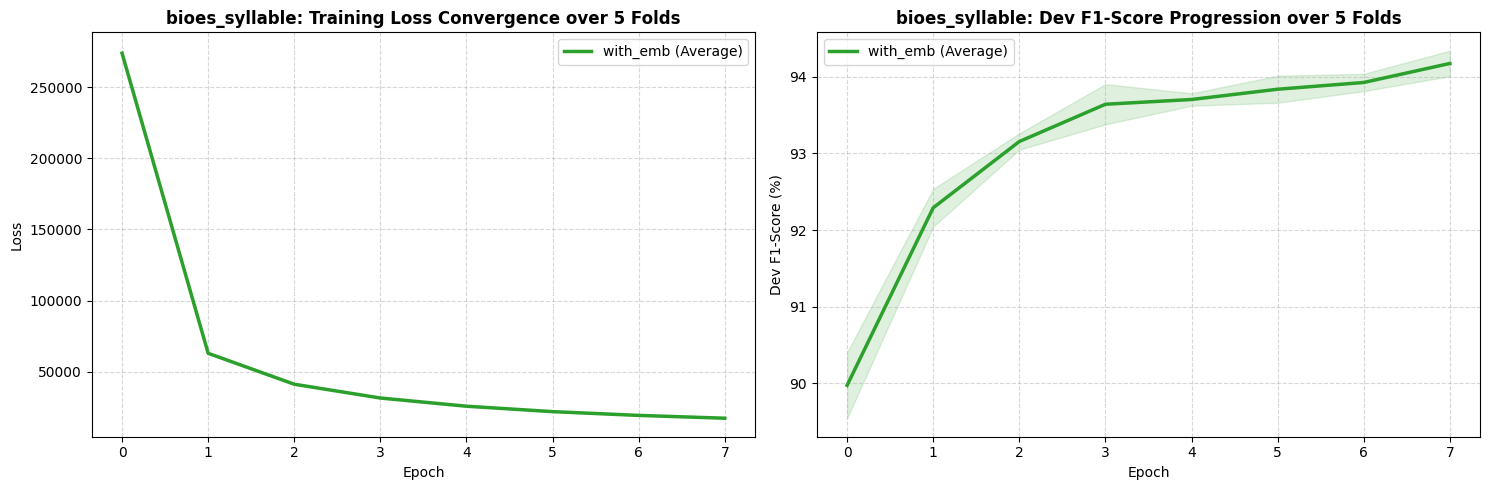

Saved convergence plot to Google Drive: /NCRFpp/output/bioes_syllable_learning_curves.png



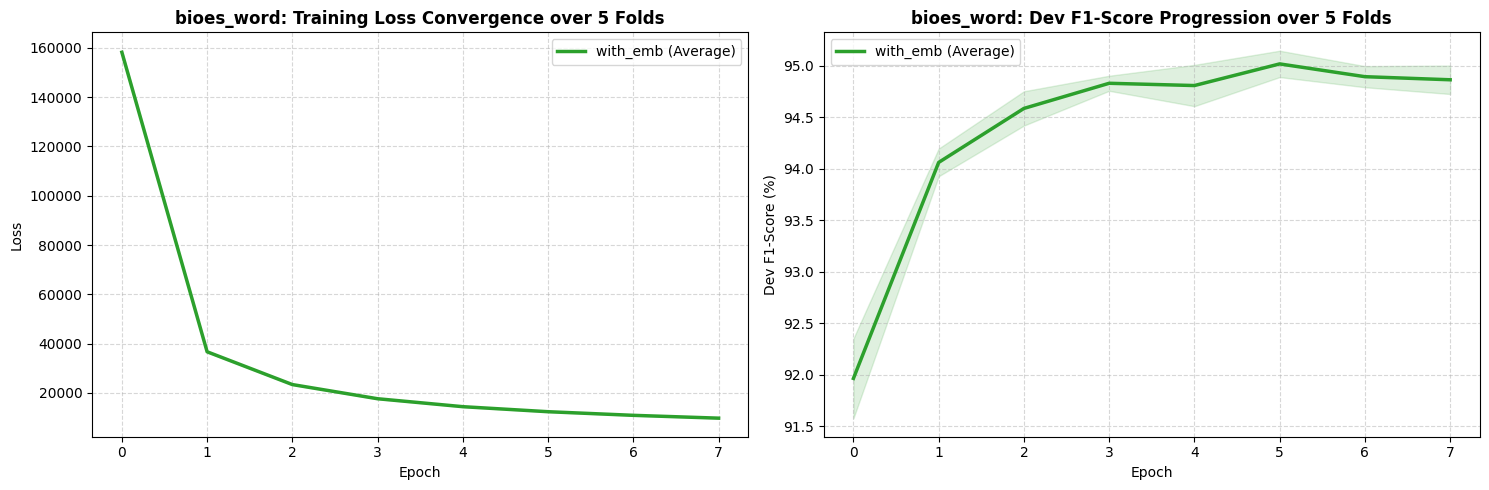

Saved convergence plot to Google Drive: /NCRFpp/output/bioes_word_learning_curves.png



In [12]:
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt

def plot_setup_learning_curves(output_dir="/NCRFpp/output"):
    history_files = glob.glob(os.path.join(output_dir, "*.history.json"))
    if not history_files:
        print("No training history files (.history.json) found on Google Drive. Please run training first!")
        return

    grouped_data = {}
    for path in history_files:
        filename = os.path.basename(path)
        name = filename.replace(".history.json", "")
        if "_fold_" not in name: continue
        parts = name.split("_fold_")
        setup_with_prefix, fold = parts[0], int(parts[1])

        setup, var = (setup_with_prefix.replace("with_emb.", ""), "with_emb") if setup_with_prefix.startswith("with_emb.") else (setup_with_prefix, "without_emb")
        key = f"{setup} ({var})"
        if key not in grouped_data: grouped_data[key] = {}

        with open(path, 'r', encoding='utf-8') as f:
            try: grouped_data[key][fold] = json.load(f)
            except Exception as e: print(f"Error loading {path}: {e}")

    setups = sorted(list(set(k.split(" (")[0] for k in grouped_data.keys())))
    for setup in setups:
        plt.figure(figsize=(15, 5))

        # --- Left Plot: Training Loss ---
        plt.subplot(1, 2, 1)
        for var in ["without_emb", "with_emb"]:
            key = f"{setup} ({var})"
            if key not in grouped_data: continue
            epoch_losses = {}
            for fold, history in grouped_data[key].items():
                for item in history:
                    ep, loss = item["epoch"], item["loss"]
                    epoch_losses.setdefault(ep, []).append(loss)
            if not epoch_losses: continue
            sorted_epochs = sorted(epoch_losses.keys())
            mean_losses = [np.mean(epoch_losses[ep]) for ep in sorted_epochs]
            std_losses = [np.std(epoch_losses[ep]) for ep in sorted_epochs]
            color = "#2ca02c" if var == "with_emb" else "#1f77b4"
            plt.plot(sorted_epochs, mean_losses, color=color, linewidth=2.5, label=f"{var} (Average)")
            plt.fill_between(sorted_epochs, np.array(mean_losses) - np.array(std_losses), np.array(mean_losses) + np.array(std_losses), color=color, alpha=0.15)

        plt.title(f"{setup}: Training Loss Convergence over 5 Folds", fontsize=12, fontweight='bold')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()

        # --- Right Plot: Validation Dev F1 ---
        plt.subplot(1, 2, 2)
        for var in ["without_emb", "with_emb"]:
            key = f"{setup} ({var})"
            if key not in grouped_data: continue
            epoch_f1s = {}
            for fold, history in grouped_data[key].items():
                for item in history:
                    ep, f1 = item["epoch"], item["f1"]
                    epoch_f1s.setdefault(ep, []).append(f1)
            if not epoch_f1s: continue
            sorted_epochs = sorted(epoch_f1s.keys())
            mean_f1s = [np.mean(epoch_f1s[ep]) for ep in sorted_epochs]
            std_f1s = [np.std(epoch_f1s[ep]) for ep in sorted_epochs]
            color = "#2ca02c" if var == "with_emb" else "#1f77b4"
            plt.plot(sorted_epochs, mean_f1s, color=color, linewidth=2.5, label=f"{var} (Average)")
            plt.fill_between(sorted_epochs, np.array(mean_f1s) - np.array(std_f1s), np.array(mean_f1s) + np.array(std_f1s), color=color, alpha=0.15)

        plt.title(f"{setup}: Dev F1-Score Progression over 5 Folds", fontsize=12, fontweight='bold')
        plt.xlabel("Epoch")
        plt.ylabel("Dev F1-Score (%)")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()

        plt.tight_layout()
        plot_save_path = os.path.join(output_dir, f"{setup}_learning_curves.png")
        plt.savefig(plot_save_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f"Saved convergence plot to Google Drive: {plot_save_path}\n")

plot_setup_learning_curves()


### Step 9: Model Diagnostic & Sequence-Level Entropy (Label Perplexity) Analysis
This advanced diagnostic step runs an **N-Best Viterbi Decoding (nbest=5)** on the test dataset using your best-performing model (`ADAM_lr0.002_drop0.3_h200_b32`).

By decoding with `nbest=5`, NCRF++ computes the relative probabilities for the top 5 alternative tag sequences of each sentence. We can then calculate **Predictive Sequence Entropy** ($H$) and **Per-token Entropy** for every sentence:
- **Low Entropy ($H \approx 0$)**: The model is extremely confident in a single, clear-cut label sequence.
- **High Entropy ($H > 1.0$)**: The model is experiencing severe "label confusion" between multiple conflicting tagging decisions.

This analysis isolates the absolute **"blind spots"** (hardest sentences) of your model, which typically represent **annotation errors, syntactic ambiguities, or rare agricultural vocabulary**!

In [10]:
import os, subprocess, numpy as np

project_root, models_root, output_root = '/NCRFpp', '/NCRFpp/models', '/NCRFpp/output'
best_setup, best_fold = "bioes_word", 0

candidates = [
    os.path.join(models_root, "sweep_bioes_word_ADAM_lr0.002_drop0.3_h200_b32.7.model"),
    os.path.join(models_root, "with_emb.bioes_word_fold_0.34.model"),
    os.path.join(models_root, "with_emb.bioes_word_fold_0.29.model"),
]
best_model_path = next((c for c in candidates if os.path.exists(c)), None)

if not best_model_path and os.path.exists(models_root):
    model_files = sorted([f for f in os.listdir(models_root) if f.endswith(".model")])
    if model_files: best_model_path = os.path.join(models_root, model_files[-1])

if not best_model_path:
    print("❌ Error: No trained model found! Please complete Step 8 training first.")
else:
    base_prefix = os.path.basename(best_model_path).split(".")[0]
    best_dset_path = os.path.join(models_root, f"{base_prefix}.dset")
    if not os.path.exists(best_dset_path):
        best_dset_path = os.path.join(models_root, f"{base_prefix.replace('.34', '').replace('.29', '').replace('.7', '')}.dset")

    if not os.path.exists(best_dset_path):
        print(f"❌ Error: Dset file not found at {best_dset_path}")
    else:
        print(f"🎯 Model: {best_model_path}\n📦 Dset: {best_dset_path}")
        diag_config_path = f"{project_root}/diagnostic.decode.config"
        diag_out_file = f"{output_root}/diagnostic_best_nbest5.test.out"

        decode_content = f"status=decode\nraw_dir={project_root}/data/{best_setup}/fold_{best_fold}/test.conll\ndecode_dir={diag_out_file}\ndset_dir={best_dset_path}\nload_model_dir={best_model_path}\nnbest=5\ngpu\n"
        with open(diag_config_path, 'w') as f: f.write(decode_content.strip())

        print("🏃‍♂️ Executing N-Best Viterbi Decoding...")
        subprocess.run(["python", "-u", f"{project_root}/main.py", "--config", diag_config_path], stdout=subprocess.DEVNULL, check=True)
        print("✅ Decoding completed successfully!")

        sentences, current_sent_tokens, current_sent_tags_matrix, current_scores = [], [], [], []
        with open(diag_out_file, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    if current_sent_tokens:
                        sentences.append({"tokens": current_sent_tokens, "tags_matrix": current_sent_tags_matrix, "scores": current_scores})
                        current_sent_tokens, current_sent_tags_matrix, current_scores = [], [], []
                    continue
                if line.startswith('#'):
                    current_scores = [float(x) for x in line.split()[1:]]
                    continue
                parts = line.split()
                if len(parts) >= 2:
                    current_sent_tokens.append(parts[0])
                    current_sent_tags_matrix.append(parts[1:])
        if current_sent_tokens:
            sentences.append({"tokens": current_sent_tokens, "tags_matrix": current_sent_tags_matrix, "scores": current_scores})

        analyzed_sents = []
        for sent in sentences:
            scores, tokens, tags_matrix = sent["scores"], sent["tokens"], sent["tags_matrix"]
            if not scores or len(tokens) == 0: continue
            scores = np.array(scores) / np.sum(scores)
            entropy = -np.sum([p * np.log2(p) for p in scores if p > 0])
            analyzed_sents.append({
                "tokens": tokens, "tags_matrix": tags_matrix, "scores": scores,
                "entropy": entropy, "perplexity": 2 ** entropy, "per_token_entropy": entropy / len(tokens)
            })

        hardest_sents = sorted(analyzed_sents, key=lambda x: x["per_token_entropy"], reverse=True)
        print("\n" + "="*85 + "\n          TOP 10 MODEL BLIND SPOTS (HIGHEST PER-TOKEN ENTROPY SENTENCES)\n" + "="*85)
        for rank, sent in enumerate(hardest_sents[:10], 1):
            print(f"\n🔥 [Rank #{rank}] Per-Token Entropy: {sent['per_token_entropy']:.4f} | Perplexity: {sent['perplexity']:.2f}")
            print(f"   Sentence: {' '.join(sent['tokens'])}")
            print("   Top predictions:")
            for id_nb in range(min(3, len(sent["scores"]))):
                pred_tags = [tags[id_nb] for tags in sent["tags_matrix"]]
                ents = [f"{tok}({tag})" for tok, tag in zip(sent["tokens"], pred_tags) if tag != 'O']
                print(f"     Path #{id_nb+1} (Prob: {sent['scores'][id_nb]*100:.1f}%): {', '.join(ents) if ents else 'None'}")
            print("-" * 85)

        disagreement_by_entity = {}
        for sent in analyzed_sents:
            tags_matrix, tokens = sent["tags_matrix"], sent["tokens"]
            for i, tags in enumerate(tags_matrix):
                if len(tags) >= 2 and tags[0] != tags[1] and tags[0] != "O":
                    disagreement_by_entity[tags[0]] = disagreement_by_entity.get(tags[0], 0) + 1

        print("\n" + "="*85 + "\n                   TAG AMBIGUITY INDEX (MOST CONFUSED ENTITY CLASSES)\n" + "="*85)
        if disagreement_by_entity:
            for entity, count in sorted(disagreement_by_entity.items(), key=lambda x: x[1], reverse=True):
                print(f"   Entity Tag: {entity:<15} | Confusion Events (Path 1 vs Path 2): {count:<4}")
        else:
            print("   No tag disagreements found across paths!")
        print("="*85)


❌ Error: Dset file not found at /NCRFpp/models/with_emb.dset


### Step 10: Backup All Experiments to Google Drive


In [11]:
from datetime import datetime

# Define Google Drive export path
drive_export_path = '/content/drive/My Drive/MyAgriNER/'
ncrfpp_backup_path = os.path.join(drive_export_path, 'NCRFpp_backup')
os.makedirs(ncrfpp_backup_path, exist_ok=True)

src_ncrfpp_dir = '/NCRFpp'
dst_ncrfpp_dir = os.path.join(ncrfpp_backup_path, datetime.now().strftime('%Y%m%d_%H%M%S'))

print(f'Starting backup of {src_ncrfpp_dir} to {dst_ncrfpp_dir}...')

if os.path.exists(src_ncrfpp_dir):
    if os.path.exists(dst_ncrfpp_dir):
        shutil.rmtree(dst_ncrfpp_dir)
    shutil.copytree(src_ncrfpp_dir, dst_ncrfpp_dir)
    print(f'\nBackup complete! The entire directory is saved in {dst_ncrfpp_dir}.')
else:
    print(f'Error: Source directory {src_ncrfpp_dir} does not exist.')


Starting backup of /NCRFpp to /content/drive/My Drive/MyAgriNER/NCRFpp_backup/20260826_141608...

Backup complete! The entire directory is saved in /content/drive/My Drive/MyAgriNER/NCRFpp_backup/20260826_141608.
